In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import numpy as np
import rioxarray
import os
import geopandas
import pandas as pd
from tqdm import tqdm
import matplotlib.gridspec as gridspec
from matplotlib.animation import FFMpegWriter
from rasterio.features import geometry_mask
import shapely
import rasterio

In [2]:

projectDir = "/Users/rfk471/Dropbox/elevation-canada"

project_crs = "EPSG:3413"

region_ids_full = ["01","02","03","04","05","06","07","08","09","10","11","12","13","14","15"]

region_ids_model = ["01","02","03","04","05","06","12","15"]

experiment = "v1-0" 

In [3]:
# lakes = geopandas.read_file(f"{projectDir}/data/initial/zheng_et_al/subglacial_lake_event_inventory_37locations.gpkg").to_crs(project_crs)

In [4]:
lakepolygons = geopandas.read_file(f"{projectDir}/data/initial/zheng_et_al/lakes_w_area.gpkg").to_crs(project_crs)

In [5]:


# # Predefine output columns
# for col in ["time", "elevation", "time_train", "elevation_train", "time_a", "elevation_a", "time_cs", "elevation_cs"]:
#     lakes[col] = None

# # Dataset configuration
# datasets = [
#     dict(
#         region_ids=region_ids_full,
#         loader=lambda region_id: xr.load_dataset(
#             f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc"
#         )["udem"].squeeze("band", drop=True),
#         time_col="time",
#         elev_col="elevation",
#     ),
#     dict(
#     region_ids=region_ids_model,
#     loader=lambda region_id: xr.load_dataset(
#         f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_train.nc"
#     )["udem"].squeeze("band", drop=True),
#     time_col="time_train",
#     elev_col="elevation_train",
#     ),
#     dict(
#         region_ids=region_ids_model,
#         loader=lambda region_id: xr.load_dataset(
#             f"{projectDir}/data/interim/region-{region_id}/ArcticDEM/ArcticDEM_raw_gathered_region-{region_id}.nc"
#         )["adem-elevation"],
#         time_col="time_a",
#         elev_col="elevation_a",
#     ),
#     dict(
#         region_ids=region_ids_full,
#         loader=lambda region_id: xr.load_dataset(
#             f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc"
#         )["cs-elevation"],
#         time_col="time_cs",
#         elev_col="elevation_cs",
#     ),
# ]

# xs = lakes.geometry.x.values
# ys = lakes.geometry.y.values

# # --- unified loop ---
# for cfg in datasets:
#     for region_id in cfg["region_ids"]:

#         da = cfg["loader"](region_id)

#         # spatial mask
#         mask = (
#             (xs >= da.x.min().item()) & (xs <= da.x.max().item()) &
#             (ys >= da.y.min().item()) & (ys <= da.y.max().item())
#         )

#         if not np.any(mask):
#             continue

#         idx_region = lakes.index[mask]
#         xs_region = xs[mask]
#         ys_region = ys[mask]

#         sampled = da.sel(
#             x=xr.DataArray(xs_region, dims="points"),
#             y=xr.DataArray(ys_region, dims="points"),
#             method="nearest"
#         )

#         valid_mask = ~sampled.isnull().all(dim="time")
#         valid_mask = np.atleast_1d(valid_mask.values)

#         if not valid_mask.any():
#             continue

#         sampled = sampled.isel(points=valid_mask)
#         idx_valid = idx_region[valid_mask]

#         time_vals = sampled.time.values
#         elev_vals = sampled.transpose("points", "time").values

#         lakes.loc[idx_valid, cfg["time_col"]] = pd.Series(
#             [time_vals] * len(idx_valid),
#             index=idx_valid
#         )

#         lakes.loc[idx_valid, cfg["elev_col"]] = pd.Series(
#             list(elev_vals),
#             index=idx_valid
#         )

In [6]:
# lakes = lakes.sort_values("no")

In [7]:
for col in [
    "time", "elevation", "coverage",
    "time_train", "elevation_train", "coverage_train",
    "time_a", "elevation_a", "coverage_a",
    "time_cs", "elevation_cs", "coverage_cs"
]:
    lakepolygons[col] = None

# Dataset configuration
datasets = [
    dict(
        region_ids=region_ids_full,
        loader=lambda region_id: xr.load_dataset(
            f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc"
        )["udem"].squeeze("band", drop=True),
        time_col="time",
        elev_col="elevation",
        cov_col = "coverage",
    ),
    dict(
    region_ids=region_ids_model,
    loader=lambda region_id: xr.load_dataset(
        f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_train.nc"
    )["udem"].squeeze("band", drop=True),
    time_col="time_train",
    elev_col="elevation_train",
    cov_col = "coverage_train",
    ),
    dict(
        region_ids=region_ids_model,
        loader=lambda region_id: xr.load_dataset(
            f"{projectDir}/data/interim/region-{region_id}/ArcticDEM/ArcticDEM_raw_gathered_region-{region_id}.nc"
        )["adem-elevation"],
        time_col="time_a",
        elev_col="elevation_a",
        cov_col = "coverage_a",
    ),
    dict(
        region_ids=region_ids_full,
        loader=lambda region_id: xr.load_dataset(
            f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc"
        )["cs-elevation"],
        time_col="time_cs",
        elev_col="elevation_cs",
        cov_col = "coverage_cs",
    ),
]

for cfg in datasets:
    for region_id in cfg["region_ids"]:

        da = cfg["loader"](region_id)

        xmin = da.x.min().item()
        xmax = da.x.max().item()
        ymin = da.y.min().item()
        ymax = da.y.max().item()

        # Select polygons overlapping raster extent
        mask = lakepolygons.geometry.intersects(
            shapely.box(xmin, ymin, xmax, ymax)
        )

        if not mask.any():
            continue

        idx_region = lakepolygons.index[mask]

        for idx in idx_region:

            poly = lakepolygons.geometry.loc[idx]

            # Raster transform
            dx = float(da.x[1] - da.x[0])
            dy = float(abs(da.y[1] - da.y[0]))

            transform = rasterio.transform.from_origin(
                xmin - dx/2,
                ymax + dy/2,
                dx,
                dy
            )

            poly_mask = geometry_mask(
                [poly],
                out_shape=(da.sizes["y"], da.sizes["x"]),
                transform=transform,
                invert=True
            )


            # Mask outside polygon
            masked = da.where(poly_mask)

            # Mean over space for every time step
            mean_ts = masked.mean(
                dim=("y", "x"),
                skipna=True
            )

            n_total = poly_mask.sum()

            coverage_ts = (masked.notnull().sum(dim=("y", "x")) / n_total * 100)

            if mean_ts.isnull().all():
                continue

            lakepolygons.at[idx, cfg["time_col"]] = mean_ts.time.values
            lakepolygons.at[idx, cfg["elev_col"]] = mean_ts.values
            lakepolygons.at[idx, cfg["cov_col"]] = coverage_ts

In [8]:
lakepolygons["area_km2"] = lakepolygons.geometry.area / 1e6

In [9]:
lakepolygons.iloc[0].lake_no

'1'

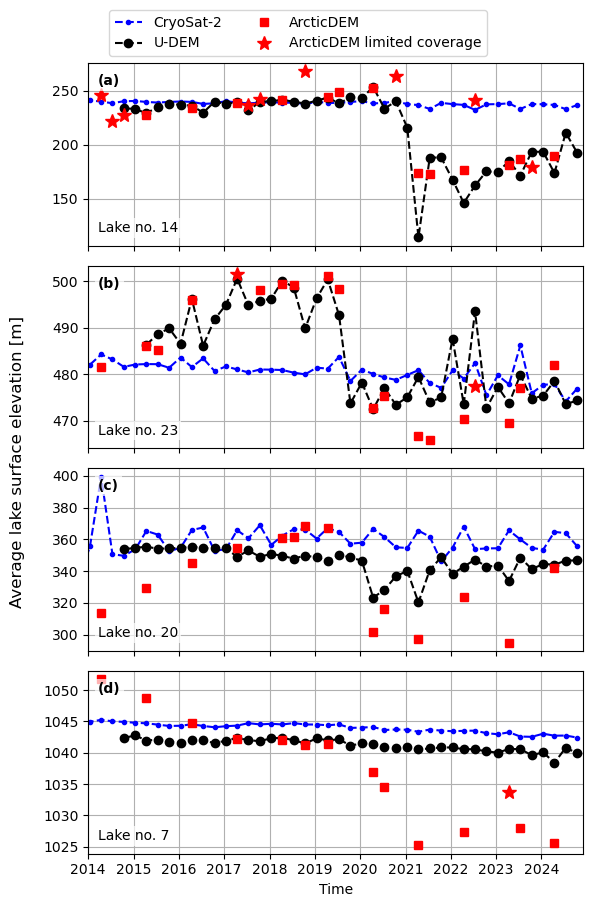

In [10]:
lake_numbers = ['14', '23', '20', '7']
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

# Keep only selected lakes and preserve the order in lake_numbers
lakes_plot = (
    lakepolygons[lakepolygons["lake_no"].isin(lake_numbers)]
    .set_index("lake_no")
    .loc[lake_numbers]
    .reset_index()
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(6, 9),
    sharex=True
)

for ax, (_, lake), panel_label in zip(axes,lakes_plot.iterrows(),panel_labels):

    t = lake["time_a"]
    z = lake["elevation_a"]

    tc = lake["time_cs"]
    zc = lake["elevation_cs"]

    # ---------------------------------------------------------
    # Handle missing data
    # ---------------------------------------------------------
    if t is None or z is None:
        t = np.array([np.nan])
        z = np.array([np.nan])

    if tc is None or zc is None:
        tc = np.array([np.nan])
        zc = np.array([np.nan])

    t = pd.to_datetime(t)
    tc = pd.to_datetime(tc)

    # ---------------------------------------------------------
    # CryoSat-2
    # ---------------------------------------------------------
    ax.plot(
        tc,
        zc,
        "--.",
        color="b",
        label="CryoSat-2"
    )

    # ---------------------------------------------------------
    # U-DEM
    # ---------------------------------------------------------
    ax.plot(
        pd.to_datetime(lake["time"]),
        lake["elevation"],
        "--o",
        color="k",
        label="U-DEM"
    )

    # ---------------------------------------------------------
    # ArcticDEM
    # ---------------------------------------------------------
    cov = lake["coverage_a"]

    if cov is not None:

        cov = np.asarray(cov)

        high = cov >= 70
        low = cov < 70

        ax.plot(
            t[high],
            z[high],
            "s",
            color="r",
            ms=6,
            label="ArcticDEM"
        )

        ax.plot(
            t[low],
            z[low],
            "*",
            color="r",
            ms=10,
            label="ArcticDEM limited coverage"
        )

    else:

        ax.plot(
            t,
            z,
            "s",
            color="r",
            ms=6,
            label="ArcticDEM"
        )



    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------
    # ax.set_title(
    #     f"Lake no. {lake['lake_no']}"
    # )

    # ax.set_ylabel(
    #     "Average lake surface elevation [m]"
    # )

    ax.grid(True)

    # Only show data from 2014 onwards
    ax.set_xlim(
        pd.Timestamp("2014-01-01"),
        pd.Timestamp("2024-12-01")
    )
    ax.text(
        0.02,
        0.06,
        f"Lake no. {lake['lake_no']}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none",
            boxstyle="square,pad=0.2"
        )
    )

    ax.text(
        0.02,
        0.94,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none",
            boxstyle="square,pad=0.2"
        )
    )

# -------------------------------------------------------------
# Shared x label
# -------------------------------------------------------------
axes[-1].set_xlabel("Time")

# -------------------------------------------------------------
# Shared legend
# -------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01),
    fontsize=10
)

fig.supylabel(
    "Average lake surface elevation [m]"
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

output_dir = f"{projectDir}/figures"
plt.savefig(f"{output_dir}/subglaciallakes_{experiment}.png",dpi=300,bbox_inches="tight")

/var/folders/0n/dl325c3168s1ns3hnk123x0c0000gn/T/ipykernel_18308/1070539349.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots()


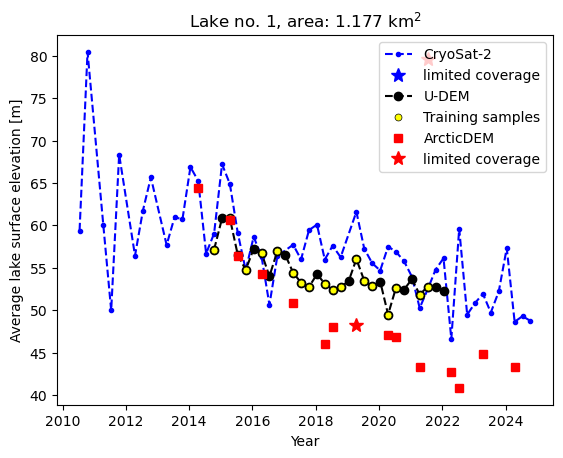

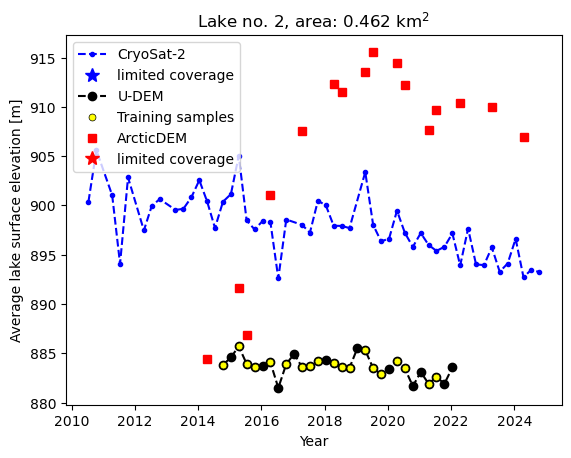

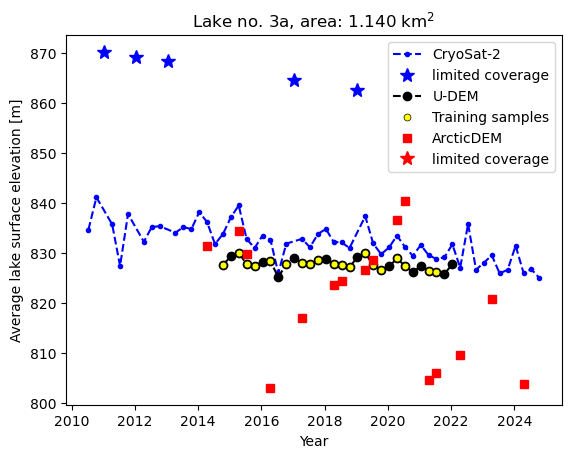

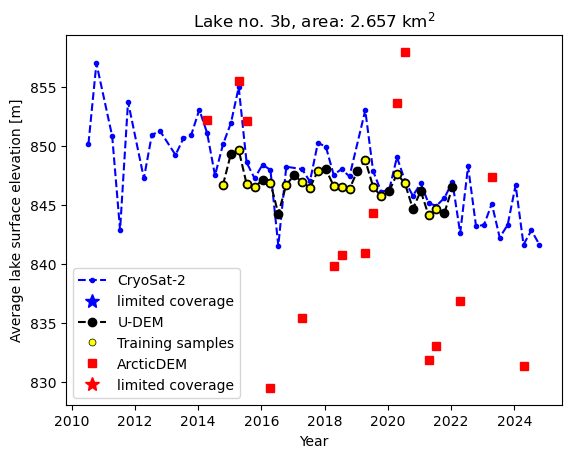

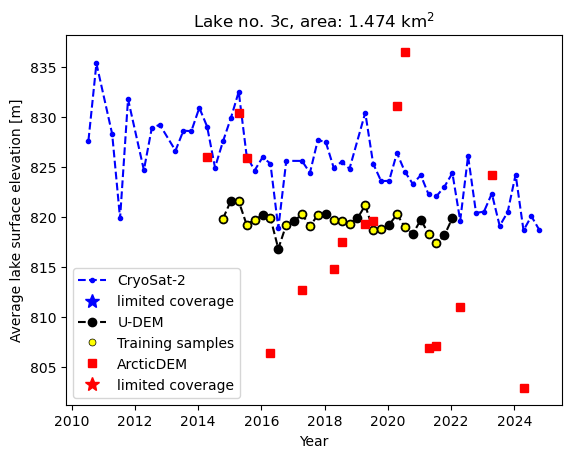

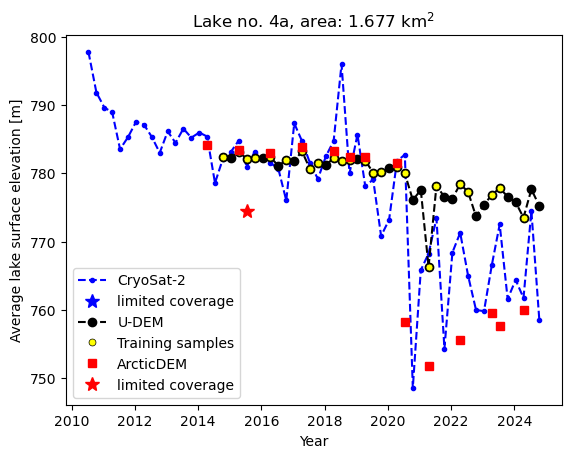

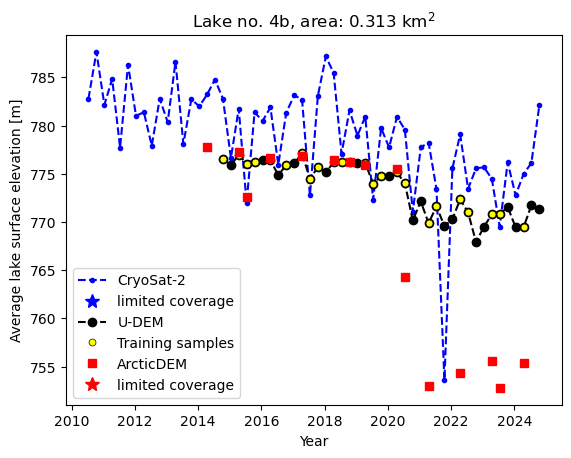

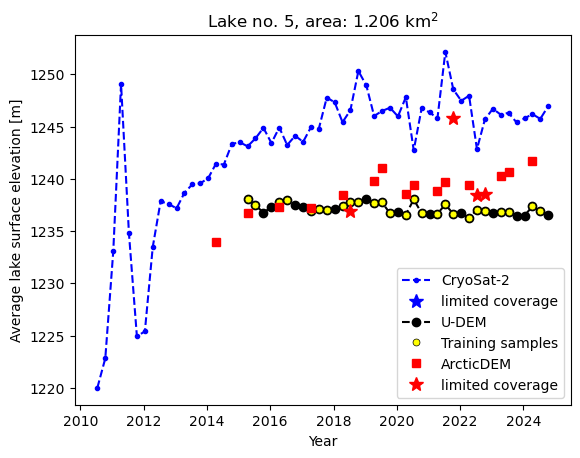

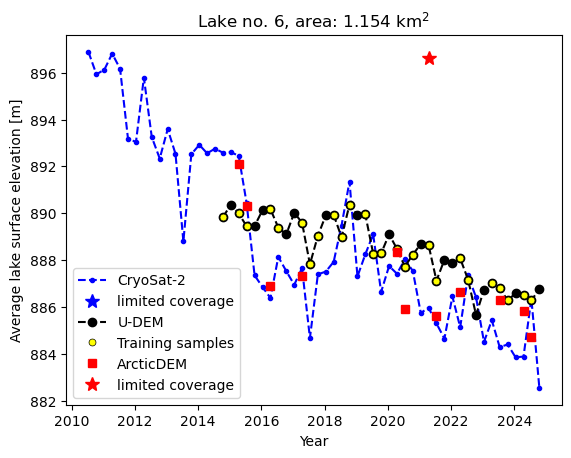

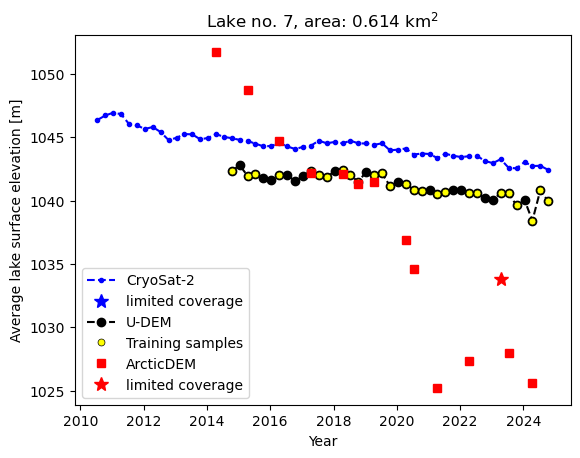

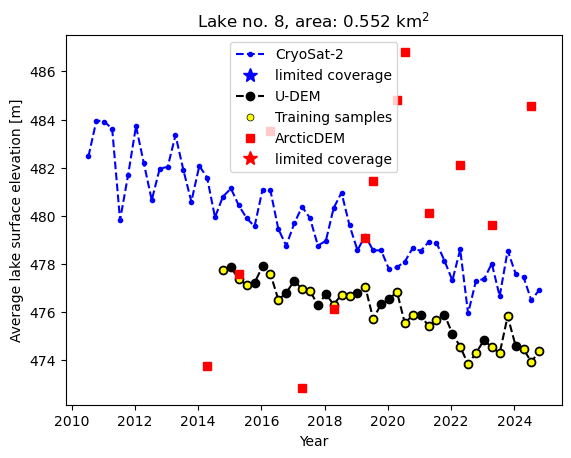

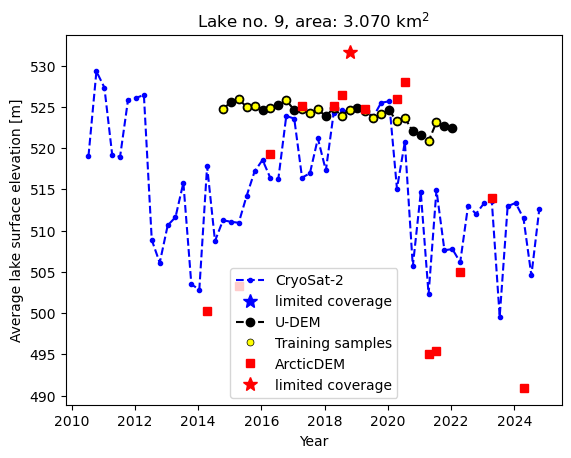

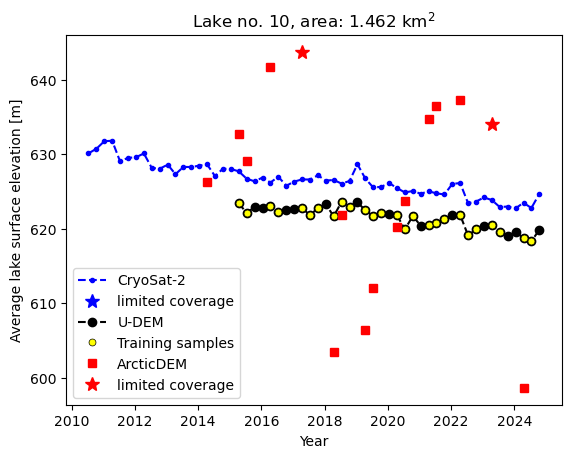

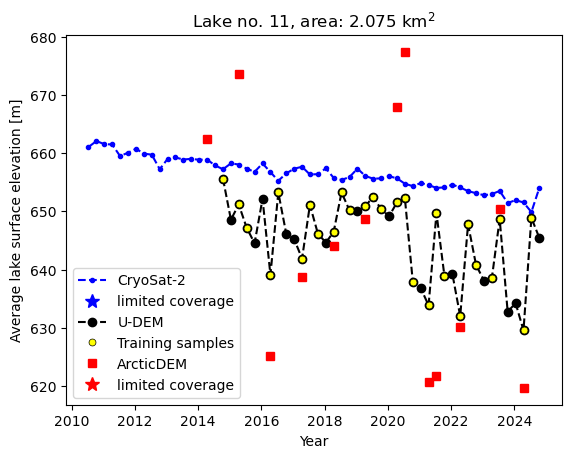

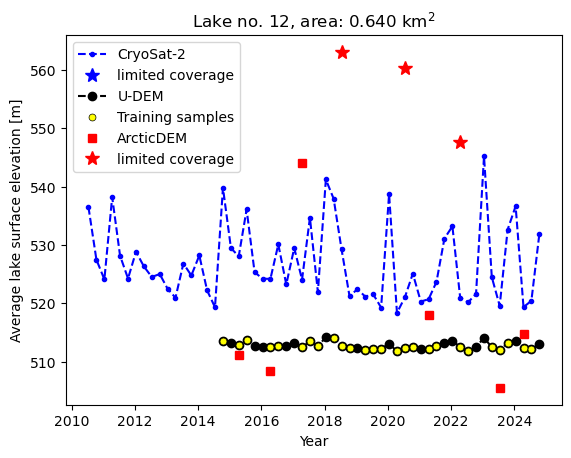

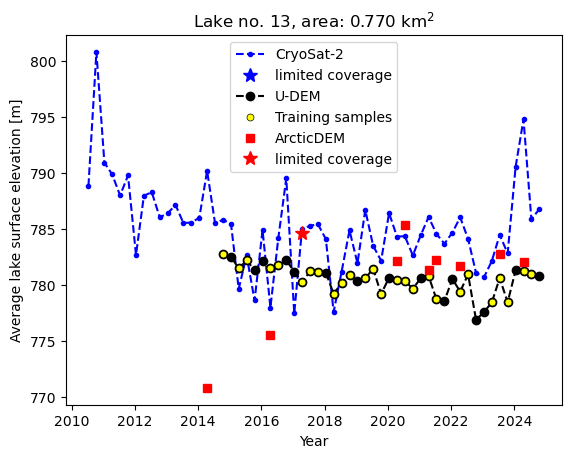

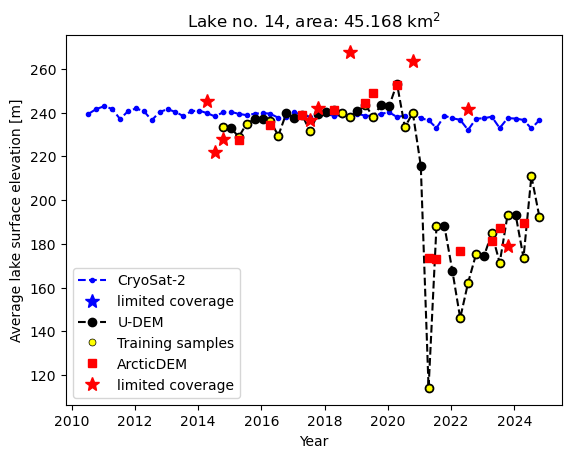

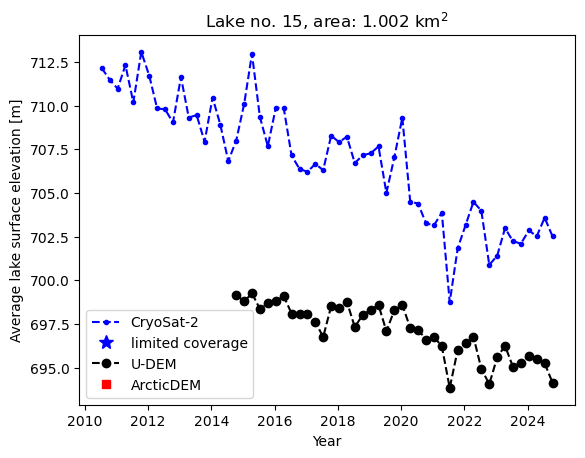

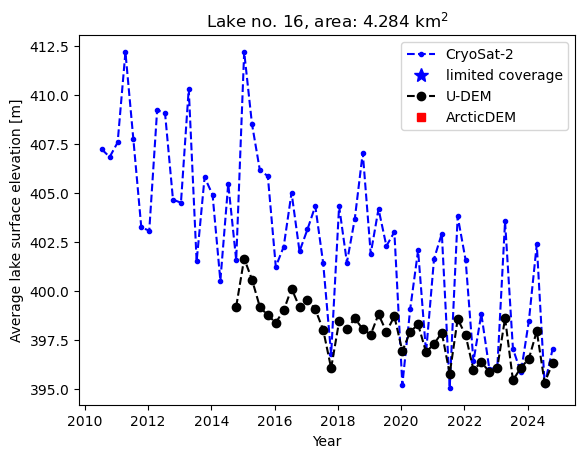

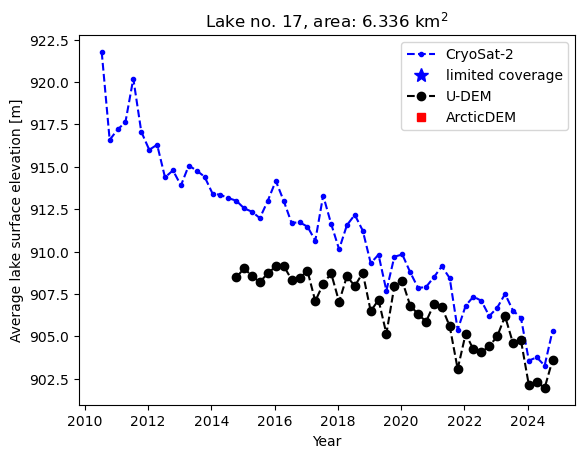

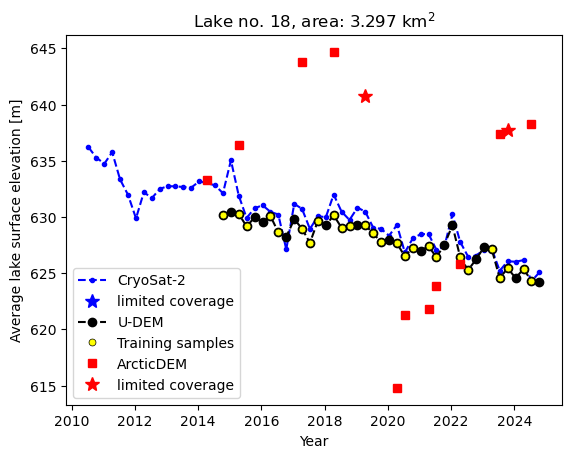

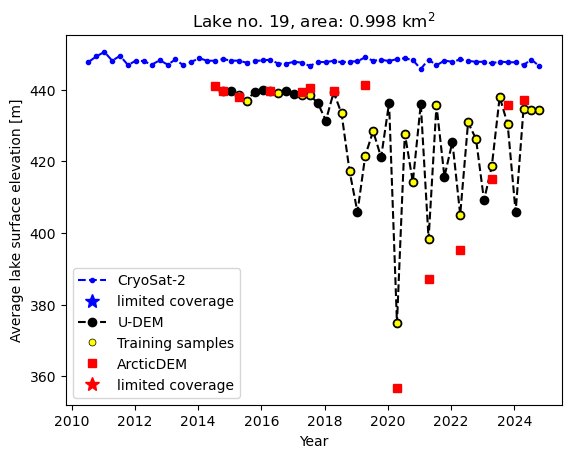

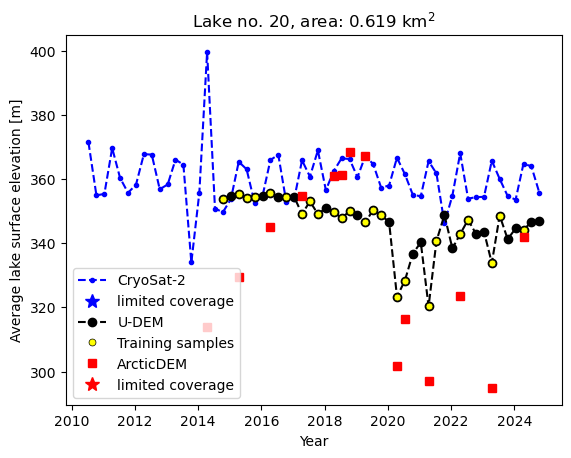

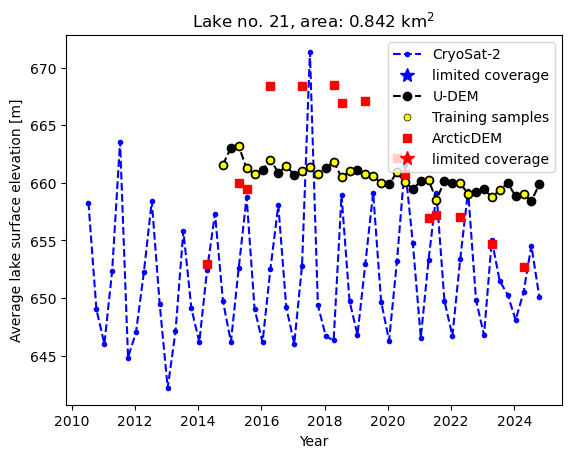

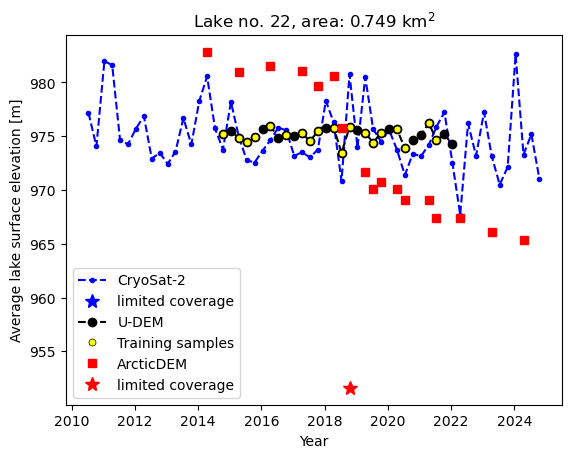

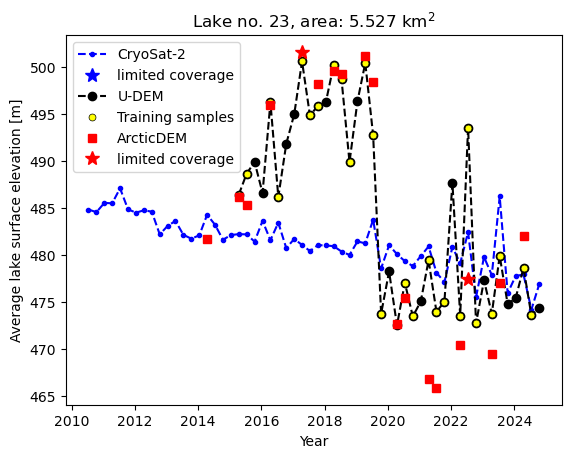

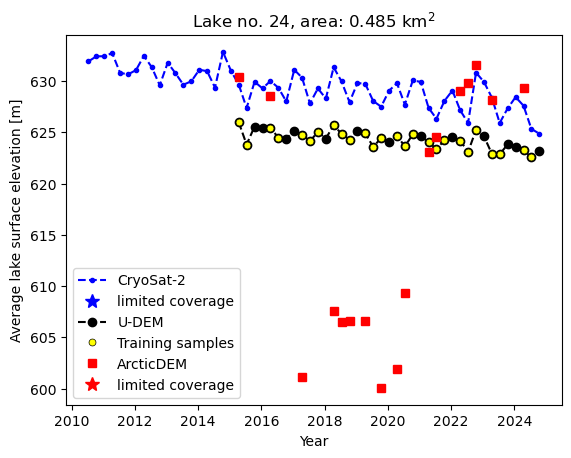

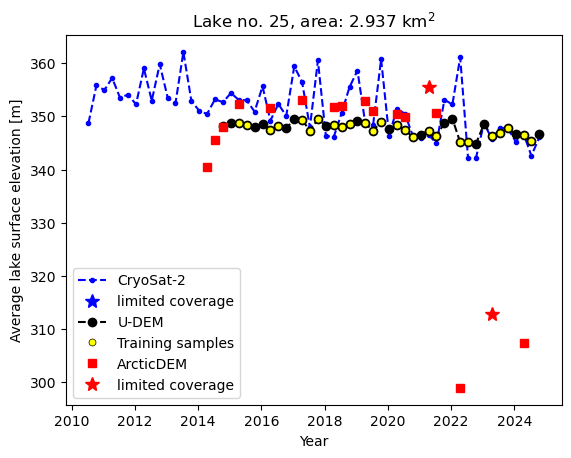

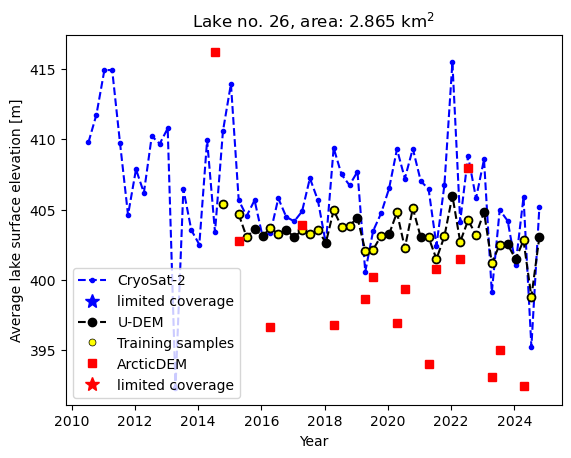

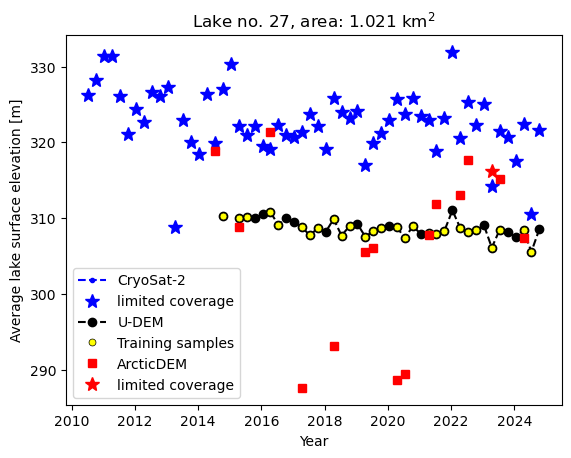

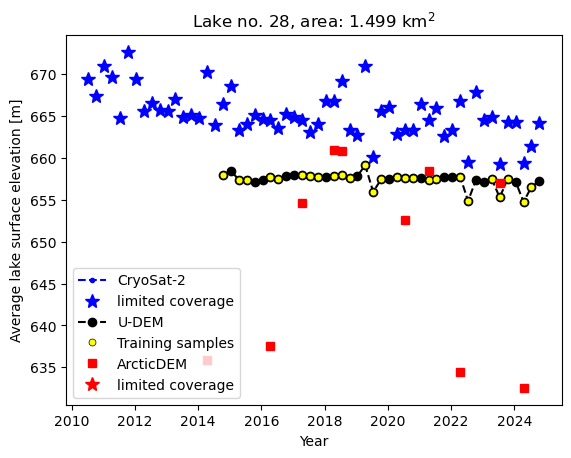

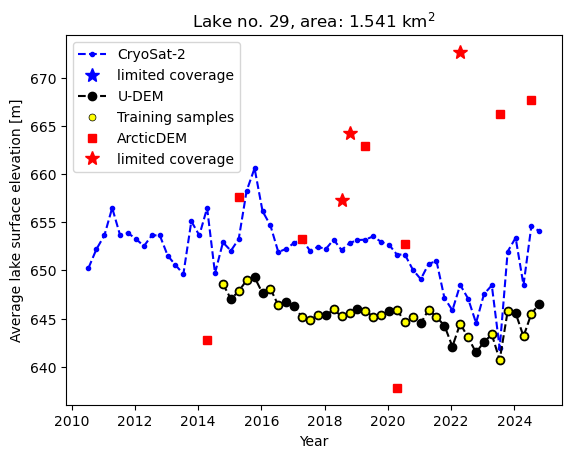

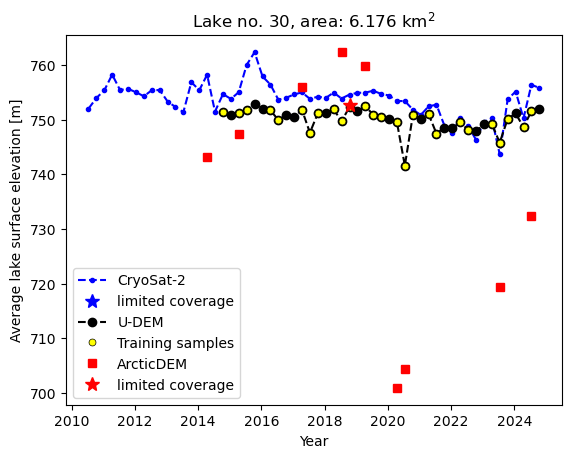

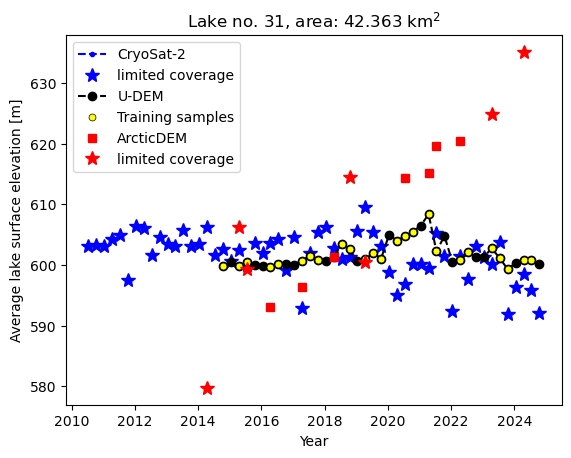

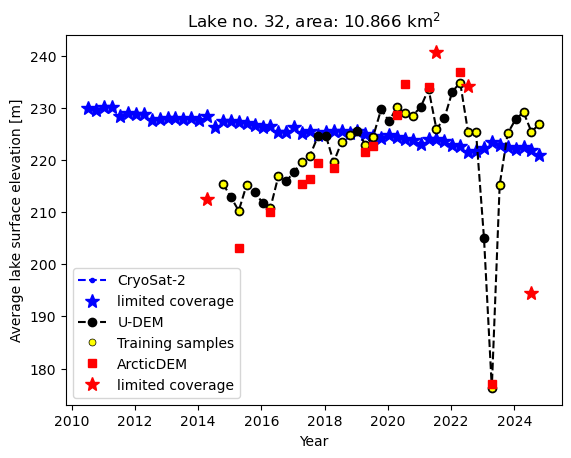

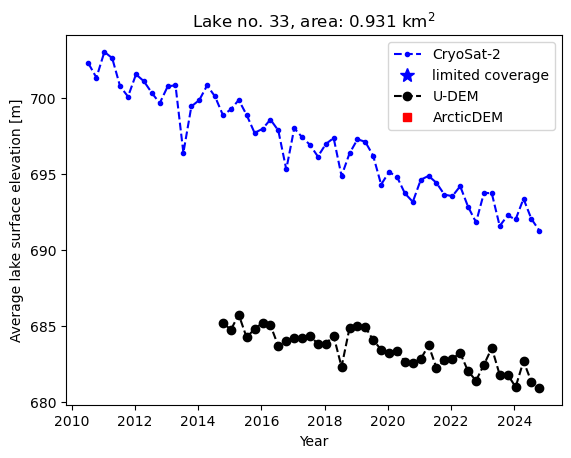

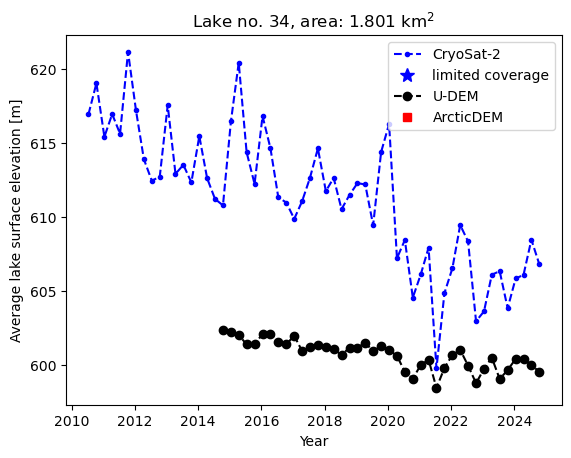

In [11]:
for i in range(len(lakepolygons)):
    t = lakepolygons.iloc[i]["time_a"]
    z = lakepolygons.iloc[i]["elevation_a"]
    tc = lakepolygons.iloc[i]["time_cs"]
    zc = lakepolygons.iloc[i]["elevation_cs"]

    if t is None or z is None:
        t = np.array([np.nan])
        z = np.array([np.nan])

    if tc is None or zc is None:
        tc = np.array([np.nan])
        zc = np.array([np.nan])


    fig,ax = plt.subplots()
    #ax.plot(tc, zc,'--.',color='b',label="CryoSat-2")
    cov_cs = lakepolygons.iloc[i]["coverage_cs"]

    if cov_cs is not None:
        cov_cs = np.asarray(cov_cs)

        high = cov_cs >= 60
        low = cov_cs < 60

        ax.plot(
            tc[high], zc[high],
            '--.', color='b',
            label='CryoSat-2'
        )

        ax.plot(
            tc[low], zc[low],
            '*', color='b', ms=10,
            label='limited coverage'
        )
    ax.plot(lakepolygons.iloc[i].time,lakepolygons.iloc[i].elevation,'--o',color='k',label="U-DEM")

    t_train = lakepolygons.iloc[i]["time_train"]
    z_train = lakepolygons.iloc[i]["elevation_train"]

    if t_train is not None and z_train is not None:

        t_all = np.asarray(lakepolygons.iloc[i]["time"])
        z_all = np.asarray(lakepolygons.iloc[i]["elevation"])

        # find U-DEM timestamps that are also in training set
        common_mask = np.isin(t_all, t_train)

        ax.plot(t_all[common_mask],z_all[common_mask],'o',ms=5,mfc='yellow',mec='k',mew=0.5,label='Training samples')

    #ax.plot(t, z,'s',color='r',ms=6,label='ArcticDEM')
    cov = lakepolygons.iloc[i]["coverage_a"]

    if cov is not None:
        cov = np.asarray(cov)

        high = cov >= 60
        low = cov < 60

        # normal observations
        ax.plot(
            t[high], z[high],
            's', color='r', ms=6,
            label='ArcticDEM'
        )

        # low-coverage observations
        ax.plot(
            t[low], z[low],
            '*', color='r', ms=10,
            label="limited coverage"
        )
    else:
        ax.plot(t, z, 's', color='r', ms=6, label='ArcticDEM')
    


    ax.set_title(f"Lake no. {lakepolygons.iloc[i]['lake_no']}, area: {lakepolygons.iloc[i]['area_km2']:.3f} km$^2$")
    plt.legend()
    ax.set_xlabel("Year")
    ax.set_ylabel("Average lake surface elevation [m]")
